# T4 Signal Explorer: early-warning behavior before churn (brandId=64)

Goal: find player behaviors that show up *before* inactivity starts, so they can work as early-warning signals (not just a post-hoc churn label).

**v0.1 scope change**: this notebook is scoped to a single brand, `brandId = 64` (`primus` only), instead of pooling every brand together. All monetary features are converted to EUR (`src/fx_rates.py`), since this brand's data is in TRY. See `docs/churn_signals_v0.md` and `docs/churn_definition_v0.md` for the full reasoning. The inactivity threshold is `60` days throughout, matching the training label decided in `02_churn_definition.ipynb`, even though this leaves only 2 complete cutoff dates to work with (see below), accepted deliberately, not a leftover default.

In [1]:
import os
os.environ["AWS_PROFILE"] = "javier-whizdom-prod-ds"

import datetime as dt
from pathlib import Path

import boto3
import duckdb
import numpy as np
import pandas as pd

import sys
sys.path.insert(0, "../src")
from fx_rates import load_fx_rates_eur, build_eur_rate_lookup, convert_amount_to_eur

BUCKET = "whizdomai-eu-central-1-650177547431-datalake-gmntc-prod"
LANDING_LEVEL = "org/10-landing/kafka-sink"
LANDING_TABLES = {
    "player": "whizdomai-players",
    "bet": "whizdomai-transactions",
    "transaction": "whizdomai-payments",
    "bonus": "whizdomai-bonuses",
}

# --- v0.1 scope change: one brand, not all brands (see docs/churn_signals_v0.md) ---
TARGET_BRAND_ID = 64
BRAND_OPERATORS = ["primus"]  # brandId=64 confirmed to exist only in primus (checked on a snapshot day)
# `bonus` has no brandId column; every partyId belongs to exactly one brandId within an operator
# (checked on a snapshot day, zero partyId had >1 distinct brandId), so bonus rows are scoped by
# an explicit partyId membership check against the brandId=64 player set, not a brandId filter.


def s3_duckdb():
    """DuckDB connection with the credentials of the SSO profile already loaded."""
    creds = boto3.Session(profile_name="javier-whizdom-prod-ds").get_credentials().get_frozen_credentials()
    con = duckdb.connect()
    con.sql("INSTALL httpfs; LOAD httpfs;")
    con.sql("SET memory_limit='16GB'")
    con.sql("SET threads=32")
    con.sql(f"""
        CREATE OR REPLACE SECRET s3_secret (
            TYPE S3, KEY_ID '{creds.access_key}', SECRET '{creds.secret_key}',
            SESSION_TOKEN '{creds.token}', REGION 'eu-central-1'
        );
    """)
    return con


def landing_paths(operator, landing_table, days):
    return [
        f"s3://{BUCKET}/{LANDING_LEVEL}/{operator}/{landing_table}/{d.year}/{d.month:02d}/{d.day:02d}/*.snappy.parquet"
        for d in days
    ]


HISTORY_START = dt.date(2026, 6, 18)
HISTORY_END = dt.date(2026, 9, 29)
HISTORY_DAYS = [HISTORY_START + dt.timedelta(days=i) for i in range((HISTORY_END - HISTORY_START).days + 1)]

FX_RATES_CSV = Path("../data/01_raw/fx_rates.csv")
# +-1 day margin: a handful of rows have activity_date one day outside [HISTORY_START, HISTORY_END],
# the known timezone-spillover quirk (local dateTime vs the UTC-day S3 partition boundary, see
# 01_profiling.ipynb). Loading rates for that 1-day margin avoids a KeyError on those rows later,
# instead of silently dropping them.
fx_rates_df = load_fx_rates_eur(
    FX_RATES_CSV, HISTORY_START - dt.timedelta(days=1), HISTORY_END + dt.timedelta(days=1)
)
get_eur_rate = build_eur_rate_lookup(fx_rates_df)
print(f"FX rates loaded: {fx_rates_df['currency'].nunique()} currencies, {len(fx_rates_df):,} rows")
print(f"TRY -> EUR on {HISTORY_END}: {get_eur_rate('TRY', HISTORY_END)}")

FX rates loaded: 119 currencies, 12,614 rows
TRY -> EUR on 2026-09-29: 0.01863


## Avoiding leakage: cutoff-date simulation

If we calculate days since last bet using each player's actual last day in the data, then a player who has already stopped betting when we look at them will obviously show signs of being inactive. In other words, the label is leaking into the features.

How to fix it: choose one or more cutoff dates T in the past. For each T:

- Features should only use activity where $activity_{date} <= T$ (only what we could have known on that day).

- The label (event_Nd) should only use activity where activity_date falls in $(T, T + N]$ (what really happened afterwards).

Each cutoff works like a separate simulated "today". Using more than one cutoff also gives us more training rows than a single snapshot.

A limit set by the data: we only have from HISTORY_START to HISTORY_END, which is 103 days of history. A valid cutoff needs enough room on both sides.

In [2]:
INACTIVITY_THRESHOLD_DAYS = 60   # matches the 60-day training label decided in 02_churn_definition.ipynb
LOOKBACK_DAYS = 30               # how far back of history each cutoff's features are allowed to look.
CUTOFF_STEP_DAYS = 7             # spacing between simulated cutoff dates.


def valid_cutoff_range(history_start, history_end, lookback_days, threshold_days):
    cutoff_min = history_start + dt.timedelta(days=lookback_days)
    cutoff_max = history_end - dt.timedelta(days=threshold_days)
    return cutoff_min, cutoff_max


cutoff_min, cutoff_max = valid_cutoff_range(HISTORY_START, HISTORY_END, LOOKBACK_DAYS, INACTIVITY_THRESHOLD_DAYS)
n_valid_days = (cutoff_max - cutoff_min).days
print(f"INACTIVITY_THRESHOLD_DAYS={INACTIVITY_THRESHOLD_DAYS}, LOOKBACK_DAYS={LOOKBACK_DAYS}")
print(f"valid cutoff range: {cutoff_min} to {cutoff_max} ({n_valid_days} days wide)")

if n_valid_days < 0:
    raise ValueError(
        f"No valid cutoff exists for threshold={INACTIVITY_THRESHOLD_DAYS}d and lookback={LOOKBACK_DAYS}d: "
        f"they need {LOOKBACK_DAYS + INACTIVITY_THRESHOLD_DAYS} days of history but only {(HISTORY_END - HISTORY_START).days} are available. "
        "Lower LOOKBACK_DAYS or INACTIVITY_THRESHOLD_DAYS."
    )

CUTOFF_DATES = []
d = cutoff_min
while d <= cutoff_max:
    CUTOFF_DATES.append(d)
    d += dt.timedelta(days=CUTOFF_STEP_DAYS)

print(f"{len(CUTOFF_DATES)} cutoff date(s): {CUTOFF_DATES}")

INACTIVITY_THRESHOLD_DAYS=60, LOOKBACK_DAYS=30
valid cutoff range: 2026-07-18 to 2026-07-31 (13 days wide)
2 cutoff date(s): [datetime.date(2026, 7, 18), datetime.date(2026, 7, 25)]


**Result.** Valid range `2026-07-18` to `2026-07-31` (13 days), giving only 2 weekly cutoffs: `2026-07-18` and `2026-07-25`.

This is thin, and we know it (see the earlier, all-brands version of this notebook, where the same 60-day threshold gave this exact same 2-cutoff range, and switching to 30 days would widen it to 7). **We are keeping 60 days anyway for this v0.1 pass**: the training label for `brandId=64` is `event_60d` (decided in `02_churn_definition.ipynb`), and matching that label here, even with fewer cutoffs, matters more for this iteration than having more rows from a threshold that is not the one the model will actually train on. More cutoffs become available naturally as history accumulates; this is not a problem to solve by changing the threshold.

## Activity-based features and the label, per cutoff

`session` does not exist as a source table (see T2); we derive day-level activity from `bet` ourselves, scoped to `brandId = 64`. The cell below generates `active_day_gaps_brand64.parquet` from S3 if it is not already in `CACHE_DIR`, or loads it straight from disk if it is (this cache is also built directly by `02_churn_definition.ipynb`'s return-after-dormancy section, same query, so if that notebook has already run, this step is instant here too).

For each cutoff `T`, from that data we build, using only `activity_date <= T`:
- `days_since_last_active`: recency as of `T`.
- `n_active_days_last_7d` / `n_active_days_prior_7d`: active days in the week right before `T` vs. the week before that, our **frequency-drop** signal (`freq_drop_7_vs_prior7 = last_7d - prior_7d`; negative means activity slowed down).
- `n_active_days_last_Nd` (`N = LOOKBACK_DAYS`): overall activity level in the full lookback window.
- `n_prior_dormancy_episodes_7d` / `max_prior_gap_days`: how many times (and how long) this player has already gone quiet for 7+ days before `T`, our **prior-dormancy** signal.

And, using only `activity_date` in `(T, T + INACTIVITY_THRESHOLD_DAYS]`:
- `event_Nd`: 1 if the player does not return in that window (churned by the label definition), 0 if they do.

In [3]:
CACHE_DIR = Path("../data/02_intermediate")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
ACTIVE_DAY_GAPS_CACHE = CACHE_DIR / f"active_day_gaps_brand{TARGET_BRAND_ID}.parquet"


def active_day_gaps(operator, days, brand_id):
    """One row per (player, active day): the next active day, and the gap to it, one brandId.

    Day-level, not minute-level: no arbitrary session-gap threshold to justify,
    and cheap enough to run over the full history (see 01_profiling.ipynb for
    why the earlier 30-minute version was dropped).
    """
    paths = landing_paths(operator, LANDING_TABLES["bet"], days)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW bet_events AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    result = con.sql(f"""
        WITH active_days AS (
            SELECT DISTINCT partyId, CAST(dateTime AS DATE) AS activity_date
            FROM bet_events
            WHERE partyId IS NOT NULL AND dateTime IS NOT NULL AND brandId = {brand_id}
        )
        SELECT partyId, activity_date,
               LEAD(activity_date) OVER (PARTITION BY partyId ORDER BY activity_date) AS next_active_date,
               ROW_NUMBER() OVER (PARTITION BY partyId ORDER BY activity_date DESC) AS rn_from_end
        FROM active_days
    """).df()
    con.close()
    result.insert(0, "operator", operator)
    result.insert(1, "brandId", brand_id)
    result["gap_to_next_days"] = (
        pd.to_datetime(result["next_active_date"]) - pd.to_datetime(result["activity_date"])
    ).dt.days
    return result


if ACTIVE_DAY_GAPS_CACHE.exists():
    activity = pd.read_parquet(ACTIVE_DAY_GAPS_CACHE)
    if "gap_to_next_days" not in activity.columns:
        activity["gap_to_next_days"] = (
            pd.to_datetime(activity["next_active_date"]) - pd.to_datetime(activity["activity_date"])
        ).dt.days
    print(f"loaded from cache: {ACTIVE_DAY_GAPS_CACHE} ({len(activity):,} player-day rows)")
else:
    frames = [active_day_gaps(operator, HISTORY_DAYS, TARGET_BRAND_ID) for operator in BRAND_OPERATORS]
    activity = pd.concat(frames, ignore_index=True)
    activity.to_parquet(ACTIVE_DAY_GAPS_CACHE)
    print(f"computed and cached to {ACTIVE_DAY_GAPS_CACHE} ({len(activity):,} player-day rows)")

activity.head()

loaded from cache: ../data/02_intermediate/active_day_gaps_brand64.parquet (238,929 player-day rows)


,operator,brandId,partyId,activity_date,next_active_date,rn_from_end,gap_to_next_days
0,primus,64,19225917,2026-08-24,2026-08-25,11,1.0
1,primus,64,19228403,2026-08-29,NaT,1,NaN
2,primus,64,19228403,2026-08-26,2026-08-29,2,3.0
3,primus,64,19230006,2026-09-06,NaT,1,NaN
4,primus,64,19232169,2026-08-24,NaT,1,NaN


In [4]:
activity["activity_date"] = pd.to_datetime(activity["activity_date"]).dt.date
activity["next_active_date"] = pd.to_datetime(activity["next_active_date"]).dt.date

player_days = activity[["operator", "partyId", "activity_date"]].drop_duplicates()


def build_snapshot(cutoff, threshold_days=INACTIVITY_THRESHOLD_DAYS, lookback_days=LOOKBACK_DAYS):
    """One row per player active by `cutoff`: trailing-window features + the event_Nd label."""
    pre = player_days[player_days["activity_date"] <= cutoff]
    post_end = cutoff + dt.timedelta(days=threshold_days)
    post = player_days[(player_days["activity_date"] > cutoff) & (player_days["activity_date"] <= post_end)]

    key = ["operator", "partyId"]
    snap = pre[key].drop_duplicates().reset_index(drop=True)

    last_active = pre.groupby(key)["activity_date"].max().rename("last_active_date")
    snap = snap.merge(last_active, on=key, how="left")
    snap["days_since_last_active"] = snap["last_active_date"].apply(lambda d: (cutoff - d).days)

    windows = {
        "n_active_days_last_7d": (cutoff - dt.timedelta(days=7), cutoff),
        "n_active_days_prior_7d": (cutoff - dt.timedelta(days=14), cutoff - dt.timedelta(days=7)),
        f"n_active_days_last_{lookback_days}d": (cutoff - dt.timedelta(days=lookback_days), cutoff),
    }
    for col, (start, end) in windows.items():
        counts = (
            pre[(pre["activity_date"] > start) & (pre["activity_date"] <= end)]
            .groupby(key).size().rename(col)
        )
        snap = snap.merge(counts, on=key, how="left")
        snap[col] = snap[col].fillna(0).astype(int)

    snap["freq_drop_7_vs_prior7"] = snap["n_active_days_last_7d"] - snap["n_active_days_prior_7d"]

    # Prior dormancy: gaps between two active days that are both <= cutoff (fully observed in the past).
    prior_gaps = activity[
        (activity["activity_date"] <= cutoff)
        & activity["next_active_date"].notna()
        & (activity["next_active_date"] <= cutoff)
    ]
    n_dormancy = (
        prior_gaps[prior_gaps["gap_to_next_days"] >= 7]
        .groupby(key).size().rename("n_prior_dormancy_episodes_7d")
    )
    max_gap = prior_gaps.groupby(key)["gap_to_next_days"].max().rename("max_prior_gap_days")
    snap = snap.merge(n_dormancy, on=key, how="left").merge(max_gap, on=key, how="left")
    snap["n_prior_dormancy_episodes_7d"] = snap["n_prior_dormancy_episodes_7d"].fillna(0).astype(int)
    snap["max_prior_gap_days"] = snap["max_prior_gap_days"].fillna(0).astype(int)

    returned = post[key].drop_duplicates()
    returned["returned"] = True
    snap = snap.merge(returned, on=key, how="left")
    snap["returned"] = snap["returned"].fillna(False)
    snap[f"event_{threshold_days}d"] = (~snap["returned"]).astype(int)
    snap = snap.drop(columns=["returned", "last_active_date"])
    snap.insert(0, "cutoff_date", cutoff)
    return snap


snapshots = pd.concat([build_snapshot(c) for c in CUTOFF_DATES], ignore_index=True)
print(f"{len(snapshots):,} (player, cutoff) rows from {len(CUTOFF_DATES)} cutoff(s)")
print(f"event_{INACTIVITY_THRESHOLD_DAYS}d rate:", snapshots[f"event_{INACTIVITY_THRESHOLD_DAYS}d"].mean().round(4))
snapshots.groupby("cutoff_date").agg(
    n_players=("partyId", "size"),
    event_rate=(f"event_{INACTIVITY_THRESHOLD_DAYS}d", "mean"),
)

/tmp/ipykernel_365453/1261767591.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  snap["returned"] = snap["returned"].fillna(False)


27,261 (player, cutoff) rows from 2 cutoff(s)
event_60d rate: 0.3848


/tmp/ipykernel_365453/1261767591.py:53: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  snap["returned"] = snap["returned"].fillna(False)


,n_players,event_rate
cutoff_date,,
2026-07-18,12502,0.351704
2026-07-25,14759,0.412765


**Result.** 2 cutoffs, 27,261 (player, cutoff) rows, overall `event_60d` rate 38.5% (35.2% at `2026-07-18`, 41.3% at `2026-07-25`).

Only 2 cutoffs because `INACTIVITY_THRESHOLD_DAYS=60` leaves a 13-day valid range (see above), and this time we are keeping 60 days deliberately rather than switching to 30 for more rows. 27,261 rows from a 30,342-player population (multiple cutoffs per player) is still enough to fit everything below.

## Tenure: days since registration


In [5]:
PLAYER_REGDATE_CACHE = Path(f"../data/02_intermediate/player_regdate_brand{TARGET_BRAND_ID}.parquet")


def player_regdate(operator, brand_id):
    paths = landing_paths(operator, LANDING_TABLES["player"], HISTORY_DAYS)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW player_events AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    df = con.sql(f"""
        SELECT DISTINCT partyId, CAST(regdate AS DATE) AS regdate
        FROM player_events WHERE brandId = {brand_id}
    """).df()
    con.close()
    df.insert(0, "operator", operator)
    return df


if PLAYER_REGDATE_CACHE.exists():
    player_regdate_df = pd.read_parquet(PLAYER_REGDATE_CACHE)
    print(f"loaded from cache: {PLAYER_REGDATE_CACHE} ({len(player_regdate_df):,} players)")
else:
    player_regdate_df = pd.concat(
        [player_regdate(operator, TARGET_BRAND_ID) for operator in BRAND_OPERATORS], ignore_index=True
    )
    PLAYER_REGDATE_CACHE.parent.mkdir(parents=True, exist_ok=True)
    player_regdate_df.to_parquet(PLAYER_REGDATE_CACHE)
    print(f"computed and cached to {PLAYER_REGDATE_CACHE} ({len(player_regdate_df):,} players)")

player_regdate_df["regdate"] = pd.to_datetime(player_regdate_df["regdate"]).dt.date

snapshots = snapshots.drop(columns=["regdate", "regdate_x", "regdate_y"], errors="ignore")
snapshots = snapshots.merge(player_regdate_df[["operator", "partyId", "regdate"]], on=["operator", "partyId"], how="left")

snapshots["tenure_days"] = (snapshots["cutoff_date"] - snapshots["regdate"]).apply(
    lambda x: x.days if pd.notna(x) else None
)
snapshots = snapshots.drop(columns=["regdate"])

print("players missing a regdate match:", snapshots["tenure_days"].isna().sum(), "/", len(snapshots))
snapshots.groupby(f"event_{INACTIVITY_THRESHOLD_DAYS}d")["tenure_days"].describe()[["mean", "50%", "min", "max"]]

loaded from cache: ../data/02_intermediate/player_regdate_brand64.parquet (64,069 players)
players missing a regdate match: 16488 / 27261


,mean,50%,min,max
event_60d,,,,
0,655.514985,649.0,0.0,2261.0
1,262.719072,28.0,0.0,2020.0


**Result.** `tenure_days` is a strong signal here too: median tenure is 649 days for players who return (`event_60d=0`) vs. 28 days for players who churn (`event_60d=1`), mean 655.5 vs 262.7 days. Same new-player-risk pattern as before, and if anything sharper for this brand (longer-tenured brand overall, see `churn_definition_v0.md`).

**Important limitation, same shape as before, different number.** 16,488 of 27,261 rows (60.5%) have no `regdate` match, higher than the all-brands figure (41.8%), consistent with `player` being a change-event stream: this brand's players, who we already know are stickier (longer median survival, see `02_churn_definition.ipynb`), are less likely to trigger a profile-change event in any given window. `tenure_days` should still be treated as missing-not-at-random.

## Deposit and bonus activity

Two more hypotheses, from the two data sources we have not used yet: a player who stops depositing, or stops engaging with bonuses, before they stop betting might be an earlier warning than betting activity alone.

- **Deposits** (`transaction` / `whizdomai-payments`): we checked `transactionType` and `status` on a snapshot day first, instead of guessing. Only `transactionType = 'DEPOSIT'` and `status = 'COMPLETED'` counts as a real deposit; `requestDate` is the event date (0% null, unlike `processDate`). Filtered to `brandId = 64` directly, `transaction` has a `brandId` column.
- **Bonus activity** (`bonus` / `whizdomai-bonuses`): any status-change event (`changeStatusTimestamp`), not filtered to a specific status, counts as engagement, granted, spent, released, etc. are all signs the player is still interacting with the bonus system. `bonus` has **no** `brandId` column, so it is scoped instead by keeping only rows whose `partyId` is in the `brandId=64` player set (safe: every `partyId` belongs to exactly one `brandId` within an operator, checked on a snapshot day).

In [6]:
DEPOSIT_DAYS_CACHE = Path(f"../data/02_intermediate/deposit_days_brand{TARGET_BRAND_ID}.parquet")
BONUS_EVENT_DAYS_CACHE = Path(f"../data/02_intermediate/bonus_event_days_brand{TARGET_BRAND_ID}.parquet")


def deposit_days_brand(operator, brand_id):
    paths = landing_paths(operator, LANDING_TABLES["transaction"], HISTORY_DAYS)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW ev AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    df = con.sql(f"""
        SELECT DISTINCT partyId, CAST(requestDate AS DATE) AS activity_date
        FROM ev
        WHERE partyId IS NOT NULL AND requestDate IS NOT NULL
          AND transactionType = 'DEPOSIT' AND status = 'COMPLETED' AND brandId = {brand_id}
    """).df()
    con.close()
    df.insert(0, "operator", operator)
    return df


def bonus_event_days_brand(operator, brand_party_ids):
    """`bonus` has no brandId column, so rows are scoped by partyId membership
    (every partyId belongs to exactly one brandId within an operator, checked earlier)."""
    paths = landing_paths(operator, LANDING_TABLES["bonus"], HISTORY_DAYS)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW ev AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    df = con.sql("""
        SELECT DISTINCT partyId, CAST(changeStatusTimestamp AS DATE) AS activity_date
        FROM ev WHERE partyId IS NOT NULL AND changeStatusTimestamp IS NOT NULL
    """).df()
    con.close()
    df = df[df["partyId"].isin(brand_party_ids)].copy()
    df.insert(0, "operator", operator)
    return df


if DEPOSIT_DAYS_CACHE.exists():
    deposit_days_df = pd.read_parquet(DEPOSIT_DAYS_CACHE)
    print(f"loaded from cache: {DEPOSIT_DAYS_CACHE} ({len(deposit_days_df):,} rows)")
else:
    deposit_days_df = pd.concat(
        [deposit_days_brand(op, TARGET_BRAND_ID) for op in BRAND_OPERATORS], ignore_index=True
    )
    DEPOSIT_DAYS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    deposit_days_df.to_parquet(DEPOSIT_DAYS_CACHE)
    print(f"computed and cached to {DEPOSIT_DAYS_CACHE} ({len(deposit_days_df):,} rows)")
deposit_days_df["activity_date"] = pd.to_datetime(deposit_days_df["activity_date"]).dt.date

if BONUS_EVENT_DAYS_CACHE.exists():
    bonus_event_days_df = pd.read_parquet(BONUS_EVENT_DAYS_CACHE)
    print(f"loaded from cache: {BONUS_EVENT_DAYS_CACHE} ({len(bonus_event_days_df):,} rows)")
else:
    brand_party_ids = set(player_regdate_df["partyId"])
    bonus_event_days_df = pd.concat(
        [bonus_event_days_brand(op, brand_party_ids) for op in BRAND_OPERATORS], ignore_index=True
    )
    BONUS_EVENT_DAYS_CACHE.parent.mkdir(parents=True, exist_ok=True)
    bonus_event_days_df.to_parquet(BONUS_EVENT_DAYS_CACHE)
    print(f"computed and cached to {BONUS_EVENT_DAYS_CACHE} ({len(bonus_event_days_df):,} rows)")
bonus_event_days_df["activity_date"] = pd.to_datetime(bonus_event_days_df["activity_date"]).dt.date


def add_recency_and_count_features(snap, event_df, prefix, lookback_days=LOOKBACK_DAYS):
    """Adds days_since_last_<prefix> and n_<prefix>_last_Nd / prior_Nd, per cutoff_date, from event_df."""
    key = ["operator", "partyId"]
    out_parts = []
    for cutoff, grp in snap.groupby("cutoff_date"):
        pre = event_df[event_df["activity_date"] <= cutoff]
        last = pre.groupby(key)["activity_date"].max().rename(f"last_{prefix}_date")
        g = grp.merge(last, on=key, how="left")
        g[f"days_since_last_{prefix}"] = g[f"last_{prefix}_date"].apply(
            lambda d: (cutoff - d).days if pd.notna(d) else np.nan
        )
        windows = {
            f"n_{prefix}_last_7d": (cutoff - dt.timedelta(days=7), cutoff),
            f"n_{prefix}_prior_7d": (cutoff - dt.timedelta(days=14), cutoff - dt.timedelta(days=7)),
        }
        for col, (start, end) in windows.items():
            counts = pre[(pre["activity_date"] > start) & (pre["activity_date"] <= end)].groupby(key).size().rename(col)
            g = g.merge(counts, on=key, how="left")
            g[col] = g[col].fillna(0).astype(int)
        g[f"{prefix}_drop_7_vs_prior7"] = g[f"n_{prefix}_last_7d"] - g[f"n_{prefix}_prior_7d"]
        g = g.drop(columns=[f"last_{prefix}_date"])
        out_parts.append(g)
    return pd.concat(out_parts, ignore_index=True)


snapshots = add_recency_and_count_features(snapshots, deposit_days_df, "deposit")
snapshots = add_recency_and_count_features(snapshots, bonus_event_days_df, "bonus")

print("missing days_since_last_deposit:", snapshots["days_since_last_deposit"].isna().sum(), "/", len(snapshots))
print("missing days_since_last_bonus:", snapshots["days_since_last_bonus"].isna().sum(), "/", len(snapshots))
snapshots.groupby(f"event_{INACTIVITY_THRESHOLD_DAYS}d")[
    ["days_since_last_deposit", "deposit_drop_7_vs_prior7", "days_since_last_bonus", "bonus_drop_7_vs_prior7"]
].mean().round(3)

loaded from cache: ../data/02_intermediate/deposit_days_brand64.parquet (168,102 rows)
loaded from cache: ../data/02_intermediate/bonus_event_days_brand64.parquet (93,469 rows)
missing days_since_last_deposit: 9928 / 27261
missing days_since_last_bonus: 17588 / 27261


,days_since_last_deposit,deposit_drop_7_vs_prior7,days_since_last_bonus,bonus_drop_7_vs_prior7
event_60d,,,,
0,7.041,0.143,5.230,0.046
1,13.494,0.021,10.139,0.017


**Result.** Same direction as before:

| Feature | event_60d = 0 (returned) | event_60d = 1 (churned) |
|---|---|---|
| days_since_last_deposit | 7.0 | 13.5 |
| deposit_drop_7_vs_prior7 | +0.14 | +0.02 |
| days_since_last_bonus | 5.2 | 10.1 |
| bonus_drop_7_vs_prior7 | +0.05 | +0.02 |

Coverage: `days_since_last_deposit` missing for 9,928 / 27,261 rows (36.4%, notably *lower* than the all-brands figure of 50.8%, this brand's players deposit more consistently); `days_since_last_bonus` missing for 17,588 (64.5%, notably *higher* than the all-brands figure of 12.8%, this brand's players engage with bonuses far less). Both differences are brand-specific facts worth keeping in mind, not noise.

## Deposit trend, session recency, GGR / net loss, RTP

- `stake = -SUM(amountReal WHERE tranType='GAME_BET')`, `win = SUM(amountReal WHERE tranType='GAME_WIN')`, both summed per day in the transaction's native currency, then converted to EUR (`src/fx_rates.py`) before any trend window is computed, every monetary feature below is in EUR, not local currency.
- **GGR / net loss** (player's perspective): `net_loss = stake - win` (positive = player lost money that period; this is the operator's GGR for that player-period).
- **RTP**: `win / stake` (undefined when `stake = 0`, left as `NaN`, not 0). RTP is a ratio of two amounts in the same currency and date, so it is unaffected by the EUR conversion either way, computing it before or after converting gives the same number, converting first just keeps every amount column in this notebook on one consistent currency.
- **Deposit trend**: same idea as the deposit recency signal, but on `SUM(processedAmount)` per day instead of a day flag (`processedAmount` is 0% null for `DEPOSIT` + `COMPLETED`, unlike `requestedAmount` which is ~98% null), also converted to EUR.

In [7]:
BET_AMOUNTS_CACHE = Path(f"../data/02_intermediate/bet_amounts_daily_brand{TARGET_BRAND_ID}_local.parquet")
DEPOSIT_AMOUNTS_CACHE = Path(f"../data/02_intermediate/deposit_amounts_daily_brand{TARGET_BRAND_ID}_local.parquet")


def bet_amounts_daily_brand(operator, brand_id):
    """Stake/win per player-day, in the bet's own currency (converted to EUR below)."""
    paths = landing_paths(operator, LANDING_TABLES["bet"], HISTORY_DAYS)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW bet_events AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    df = con.sql(f"""
        SELECT partyId, CAST(dateTime AS DATE) AS activity_date, currency,
               -SUM(CASE WHEN tranType = 'GAME_BET' THEN amountReal ELSE 0 END) AS stake_local,
               SUM(CASE WHEN tranType = 'GAME_WIN' THEN amountReal ELSE 0 END) AS win_local
        FROM bet_events
        WHERE partyId IS NOT NULL AND dateTime IS NOT NULL AND rolledBack = False
          AND tranType IN ('GAME_BET', 'GAME_WIN') AND brandId = {brand_id}
        GROUP BY partyId, CAST(dateTime AS DATE), currency
    """).df()
    con.close()
    df.insert(0, "operator", operator)
    return df


def deposit_amounts_daily_brand(operator, brand_id):
    """Deposit amount per player-day, in the deposit's own currency (converted to EUR below).

    `transaction` (`whizdomai-payments`) has no `currency` column at all before
    `2026-08-27` (a real schema change in the source, confirmed by checking the
    per-day file schema directly, not a random null), so `union_by_name=True`
    backfills NULL for every row before that date. Verified: in the days where
    the column does exist, 100% of this brand's transaction currency values are
    TRY, matching `bet`'s currency (also 100% TRY for this brand). We fill the
    pre-2026-08-27 gap with TRY as a documented assumption, not a value actually
    present in the source for those specific rows.
    """
    paths = landing_paths(operator, LANDING_TABLES["transaction"], HISTORY_DAYS)
    con = s3_duckdb()
    con.sql(f"CREATE OR REPLACE VIEW txn AS SELECT * FROM read_parquet({paths}, union_by_name=True)")
    df = con.sql(f"""
        SELECT partyId, CAST(requestDate AS DATE) AS activity_date, currency,
               SUM(processedAmount) AS deposit_amount_local
        FROM txn
        WHERE transactionType = 'DEPOSIT' AND status = 'COMPLETED' AND brandId = {brand_id}
          AND partyId IS NOT NULL AND requestDate IS NOT NULL
        GROUP BY partyId, CAST(requestDate AS DATE), currency
    """).df()
    con.close()
    n_missing_currency = df["currency"].isna().sum()
    if n_missing_currency:
        print(f"  filling {n_missing_currency} rows with no `currency` (pre-2026-08-27 schema gap) as TRY")
        df["currency"] = df["currency"].fillna("TRY")
    df.insert(0, "operator", operator)
    return df


def load_or_build_amounts(cache_path, builder_fn):
    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        print(f"loaded from cache: {cache_path} ({len(df):,} rows)")
    else:
        df = pd.concat([builder_fn(op, TARGET_BRAND_ID) for op in BRAND_OPERATORS], ignore_index=True)
        cache_path.parent.mkdir(parents=True, exist_ok=True)
        df.to_parquet(cache_path)
        print(f"computed and cached to {cache_path} ({len(df):,} rows)")
    df["activity_date"] = pd.to_datetime(df["activity_date"]).dt.date
    return df


bet_amounts_df = load_or_build_amounts(BET_AMOUNTS_CACHE, bet_amounts_daily_brand)
deposit_amounts_df = load_or_build_amounts(DEPOSIT_AMOUNTS_CACHE, deposit_amounts_daily_brand)

print("bet currencies:", sorted(bet_amounts_df["currency"].unique()))
print("deposit currencies:", sorted(deposit_amounts_df["currency"].unique()))

# --- EUR conversion (src/fx_rates.py): everything downstream of this point is in EUR ---
bet_amounts_df["stake"] = convert_amount_to_eur(bet_amounts_df, "stake_local", "currency", "activity_date", fx_rates_df)
bet_amounts_df["win"] = convert_amount_to_eur(bet_amounts_df, "win_local", "currency", "activity_date", fx_rates_df)
deposit_amounts_df["deposit_amount"] = convert_amount_to_eur(
    deposit_amounts_df, "deposit_amount_local", "currency", "activity_date", fx_rates_df
)


def add_amount_trend_features(snap, amounts_df, amount_cols, prefix):
    """Sums `amount_cols` (already in EUR) over the last/prior 7d windows before each cutoff, per player."""
    key = ["operator", "partyId"]
    out_parts = []
    for cutoff, grp in snap.groupby("cutoff_date"):
        pre = amounts_df[amounts_df["activity_date"] <= cutoff]
        last7 = pre[pre["activity_date"] > cutoff - dt.timedelta(days=7)].groupby(key)[amount_cols].sum()
        prior7 = pre[
            (pre["activity_date"] > cutoff - dt.timedelta(days=14))
            & (pre["activity_date"] <= cutoff - dt.timedelta(days=7))
        ].groupby(key)[amount_cols].sum()
        last7 = last7.add_suffix("_last_7d")
        prior7 = prior7.add_suffix("_prior_7d")
        g = grp.merge(last7, on=key, how="left").merge(prior7, on=key, how="left")
        for col in last7.columns.tolist() + prior7.columns.tolist():
            g[col] = g[col].fillna(0.0)
        out_parts.append(g)
    return pd.concat(out_parts, ignore_index=True)


snapshots = add_amount_trend_features(snapshots, bet_amounts_df, ["stake", "win"], "bet")
snapshots = add_amount_trend_features(snapshots, deposit_amounts_df, ["deposit_amount"], "deposit")

snapshots["net_loss_last_7d"] = snapshots["stake_last_7d"] - snapshots["win_last_7d"]
snapshots["net_loss_prior_7d"] = snapshots["stake_prior_7d"] - snapshots["win_prior_7d"]
snapshots["net_loss_trend"] = snapshots["net_loss_last_7d"] - snapshots["net_loss_prior_7d"]
snapshots["rtp_last_7d"] = np.where(
    snapshots["stake_last_7d"] > 0, snapshots["win_last_7d"] / snapshots["stake_last_7d"], np.nan
)
snapshots["deposit_amount_trend"] = snapshots["deposit_amount_last_7d"] - snapshots["deposit_amount_prior_7d"]

cols = ["net_loss_last_7d", "net_loss_trend", "rtp_last_7d", "deposit_amount_last_7d", "deposit_amount_trend"]
print("rtp_last_7d undefined (stake_last_7d == 0):", snapshots["rtp_last_7d"].isna().sum(), "/", len(snapshots))
snapshots.groupby(f"event_{INACTIVITY_THRESHOLD_DAYS}d")[cols].mean().round(2)

loaded from cache: ../data/02_intermediate/bet_amounts_daily_brand64_local.parquet (234,741 rows)
loaded from cache: ../data/02_intermediate/deposit_amounts_daily_brand64_local.parquet (168,417 rows)
bet currencies: ['TRY']
deposit currencies: ['TRY']
rtp_last_7d undefined (stake_last_7d == 0): 16921 / 27261


,net_loss_last_7d,net_loss_trend,rtp_last_7d,deposit_amount_last_7d,deposit_amount_trend
event_60d,,,,,
0,59.4,5.81,0.80,170.24,-2.90
1,2.9,0.66,0.66,7.03,-2.94


**Result.** All amounts below are in EUR (`src/fx_rates.py`, this brand's native currency is TRY):

| Feature | event_60d = 0 (returned) | event_60d = 1 (churned) |
|---|---|---|
| net_loss_last_7d | €59.4 | €2.9 |
| net_loss_trend | +€5.8 | +€0.7 |
| deposit_amount_last_7d | €170.2 | €7.0 |
| deposit_amount_trend | -€2.9 | -€2.9 |
| rtp_last_7d (median, when defined) | 0.83 | 0.69 |

`rtp_last_7d` repeats the all-brands finding: churners have a visibly worse recent return (69% median vs. 83%), but it is only defined for 10,340 / 27,261 rows (37.9%, `stake_last_7d > 0`), higher coverage than the all-brands pass (21.1%) since this is a smaller, more concentrated population. Unlike the all-brands version, `deposit_amount_trend` is essentially flat and *negative for both classes* here (-€2.9 either way), not a clean split, worth re-checking once more cutoffs are available (only 2 here, see above), the same confound with the across-cutoff calendar trend noted in the all-brands pass likely still applies with even less data to average it out.

## Summary

v0.1: scoped to `brandId=64`, all amounts in EUR, `INACTIVITY_THRESHOLD_DAYS=60`. The feature matrix built below is saved for later notebooks (modeling) so they do not have to rebuild it.

In [8]:
SNAPSHOTS_CACHE = Path(f"../data/02_intermediate/signal_snapshots_brand{TARGET_BRAND_ID}_{INACTIVITY_THRESHOLD_DAYS}d.parquet")
snapshots.to_parquet(SNAPSHOTS_CACHE)
print(f"saved {SNAPSHOTS_CACHE} ({len(snapshots):,} rows, {snapshots.shape[1]} columns)")

SNAPSHOTS_OUTPUT = Path(f"../data/03_output/signal_snapshots_brand{TARGET_BRAND_ID}_{INACTIVITY_THRESHOLD_DAYS}d.parquet")
SNAPSHOTS_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
snapshots.to_parquet(SNAPSHOTS_OUTPUT)
print(f"saved {SNAPSHOTS_OUTPUT} (final table, same content)")

print(list(snapshots.columns))

saved ../data/02_intermediate/signal_snapshots_brand64_60d.parquet (27,261 rows, 31 columns)
saved ../data/03_output/signal_snapshots_brand64_60d.parquet (final table, same content)
['cutoff_date', 'operator', 'partyId', 'days_since_last_active', 'n_active_days_last_7d', 'n_active_days_prior_7d', 'n_active_days_last_30d', 'freq_drop_7_vs_prior7', 'n_prior_dormancy_episodes_7d', 'max_prior_gap_days', 'event_60d', 'tenure_days', 'days_since_last_deposit', 'n_deposit_last_7d', 'n_deposit_prior_7d', 'deposit_drop_7_vs_prior7', 'days_since_last_bonus', 'n_bonus_last_7d', 'n_bonus_prior_7d', 'bonus_drop_7_vs_prior7', 'stake_last_7d', 'win_last_7d', 'stake_prior_7d', 'win_prior_7d', 'deposit_amount_last_7d', 'deposit_amount_prior_7d', 'net_loss_last_7d', 'net_loss_prior_7d', 'net_loss_trend', 'rtp_last_7d', 'deposit_amount_trend']


In [9]:
snapshots

,cutoff_date,operator,partyId,days_since_last_active,n_active_days_last_7d,n_active_days_prior_7d,n_active_days_last_30d,freq_drop_7_vs_prior7,n_prior_dormancy_episodes_7d,max_prior_gap_days,...,win_last_7d,stake_prior_7d,win_prior_7d,deposit_amount_last_7d,deposit_amount_prior_7d,net_loss_last_7d,net_loss_prior_7d,net_loss_trend,rtp_last_7d,deposit_amount_trend
0,2026-07-18,primus,13423241,1,4,4,18,0,0,3,...,1291.412039,3456.399867,3556.649760,849.528,703.2825,849.555945,-100.249893,949.805838,0.603191,146.2455
1,2026-07-18,primus,13502818,13,0,1,6,-1,0,4,...,0.000000,0.055890,0.042849,0.000,0.0000,0.000000,0.013041,-0.013041,NaN,0.0000
2,2026-07-18,primus,13507925,3,2,0,3,2,1,18,...,0.000000,0.000000,0.000000,0.000,0.0000,0.000000,0.000000,0.000000,NaN,0.0000
3,2026-07-18,primus,13667280,8,0,1,8,-1,1,7,...,0.000000,579.325746,1026.445746,0.000,204.9300,0.000000,-447.120000,447.120000,NaN,-204.9300
4,2026-07-18,primus,13765844,16,0,0,1,0,0,0,...,0.000000,0.000000,0.000000,0.000,0.0000,0.000000,0.000000,0.000000,NaN,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27256,2026-07-25,primus,13877168,1,4,5,16,-1,0,6,...,390.261240,3536.506818,2958.976818,353.970,577.5300,353.970000,577.530000,-223.560000,0.524382,-223.5600
27257,2026-07-25,primus,13982912,5,1,0,1,1,0,0,...,4.773006,0.000000,0.000000,9.315,0.0000,9.315000,0.000000,9.315000,0.338799,9.3150
27258,2026-07-25,primus,14009181,30,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000,0.0000,0.000000,0.000000,0.000000,NaN,0.0000
27259,2026-07-25,primus,14047220,34,0,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000,0.0000,0.000000,0.000000,0.000000,NaN,0.0000


## Statistical analysis:


### lift per feature

For each candidate feature, we ask: how well does it separate churned (`event_30d=1`) from active players, on its own (univariate)?

**Method**: split each feature into deciles (`pd.qcut`, 10 quantile bins; features with many repeated values, mostly 0, collapse into fewer bins since `qcut` drops duplicate edges, that is expected, not a bug). For each bin, compute its churn rate, then:

```
lift(bin) = churn_rate(bin) / overall_churn_rate
```

- `lift = 1` means that bin churns at the baseline rate (no information)

- `lift > 1` means that bin churns more than baseline

- `lift < 1` means less



In [10]:
LABEL = f"event_{INACTIVITY_THRESHOLD_DAYS}d"


def lift_table(df, feature, label_col=LABEL, n_bins=10):
    """Decile lift table for `feature` against `label_col`. Missing values get their own row."""
    sub = df[[feature, label_col]].copy()
    present = sub[sub[feature].notna()].copy()
    missing = sub[sub[feature].isna()]
    overall = sub[label_col].mean()

    present["bin"] = pd.qcut(present[feature], n_bins, duplicates="drop")
    table = (
        present.groupby("bin", observed=True)
        .agg(n=(label_col, "size"), event_rate=(label_col, "mean"))
        .reset_index()
    )
    table["lift"] = table["event_rate"] / overall

    if len(missing):
        miss_row = pd.DataFrame([{
            "bin": "missing", "n": len(missing),
            "event_rate": missing[label_col].mean(),
            "lift": missing[label_col].mean() / overall,
        }])
        table = pd.concat([table, miss_row], ignore_index=True)
    return table, overall


CANDIDATE_FEATURES = [
    "days_since_last_active", "n_active_days_last_7d", "freq_drop_7_vs_prior7",
    "n_prior_dormancy_episodes_7d", "max_prior_gap_days", "tenure_days",
    "days_since_last_deposit", "deposit_drop_7_vs_prior7", "deposit_amount_trend",
    "days_since_last_bonus", "bonus_drop_7_vs_prior7",
    "net_loss_last_7d", "net_loss_trend", "rtp_last_7d",
]

summary_rows = []
for feat in CANDIDATE_FEATURES:
    t, overall = lift_table(snapshots, feat)
    non_missing = t[t["bin"] != "missing"]
    max_lift, min_lift = non_missing["lift"].max(), non_missing["lift"].min()
    summary_rows.append({
        "feature": feat,
        "n_bins": len(non_missing),
        "min_lift": round(min_lift, 3),
        "max_lift": round(max_lift, 3),
        "spread (max/min)": round(max_lift / min_lift, 2) if min_lift > 0 else float("inf"),
        "pct_missing": round(100 * snapshots[feat].isna().sum() / len(snapshots), 1),
    })

lift_summary = pd.DataFrame(summary_rows).sort_values("spread (max/min)", ascending=False).reset_index(drop=True)
lift_summary

,feature,n_bins,min_lift,max_lift,spread (max/min),pct_missing
0,n_active_days_last_7d,4,0.024,1.330,56.09,0.0
1,net_loss_last_7d,5,0.107,1.288,12.06,0.0
2,freq_drop_7_vs_prior7,6,0.146,1.284,8.80,0.0
3,deposit_drop_7_vs_prior7,4,0.162,1.365,8.43,0.0
4,deposit_amount_trend,6,0.177,1.471,8.29,0.0
5,net_loss_trend,6,0.186,1.482,7.96,0.0
6,days_since_last_deposit,9,0.179,1.203,6.73,36.4
7,n_prior_dormancy_episodes_7d,2,0.168,1.064,6.32,0.0
8,max_prior_gap_days,7,0.278,1.718,6.18,0.0
9,rtp_last_7d,10,0.141,0.739,5.25,62.1


In [11]:
from IPython.display import display

# Full decile tables for the two features with the most interesting shape:
# tenure_days (non-monotonic) and rtp_last_7d (missingness itself carries signal).
for feat in ["tenure_days", "rtp_last_7d"]:
    t, overall = lift_table(snapshots, feat)
    print(f"\n--- {feat} (overall rate {overall:.3f}) ---")
    display(t)


--- tenure_days (overall rate 0.385) ---


,bin,n,event_rate,lift
0,"(-0.001, 5.0]",1106,0.616637,1.602644
1,"(5.0, 13.0]",1088,0.628676,1.633935
2,"(13.0, 25.0]",1039,0.699711,1.818556
3,"(25.0, 65.0]",1078,0.690167,1.793750
4,"(65.0, 232.0]",1081,0.497687,1.293494
5,"(232.0, 515.0]",1074,0.270950,0.704201
6,"(515.0, 816.0]",1078,0.240260,0.624437
7,"(816.0, 1021.0]",1077,0.204271,0.530902
8,"(1021.0, 1267.0]",1077,0.166202,0.431961
9,"(1267.0, 2261.0]",1075,0.226047,0.587497



--- rtp_last_7d (overall rate 0.385) ---


,bin,n,event_rate,lift
0,"(-0.001, 0.375]",1034,0.284333,0.738983
1,"(0.375, 0.568]",1034,0.221470,0.575602
2,"(0.568, 0.674]",1034,0.186654,0.485115
3,"(0.674, 0.754]",1034,0.147969,0.384573
4,"(0.754, 0.816]",1034,0.121857,0.316707
5,"(0.816, 0.866]",1034,0.105416,0.273977
6,"(0.866, 0.911]",1034,0.109284,0.284031
7,"(0.911, 0.96]",1034,0.108317,0.281517
8,"(0.96, 1.056]",1034,0.054159,0.140759
9,"(1.056, 8.313]",1034,0.081238,0.211138


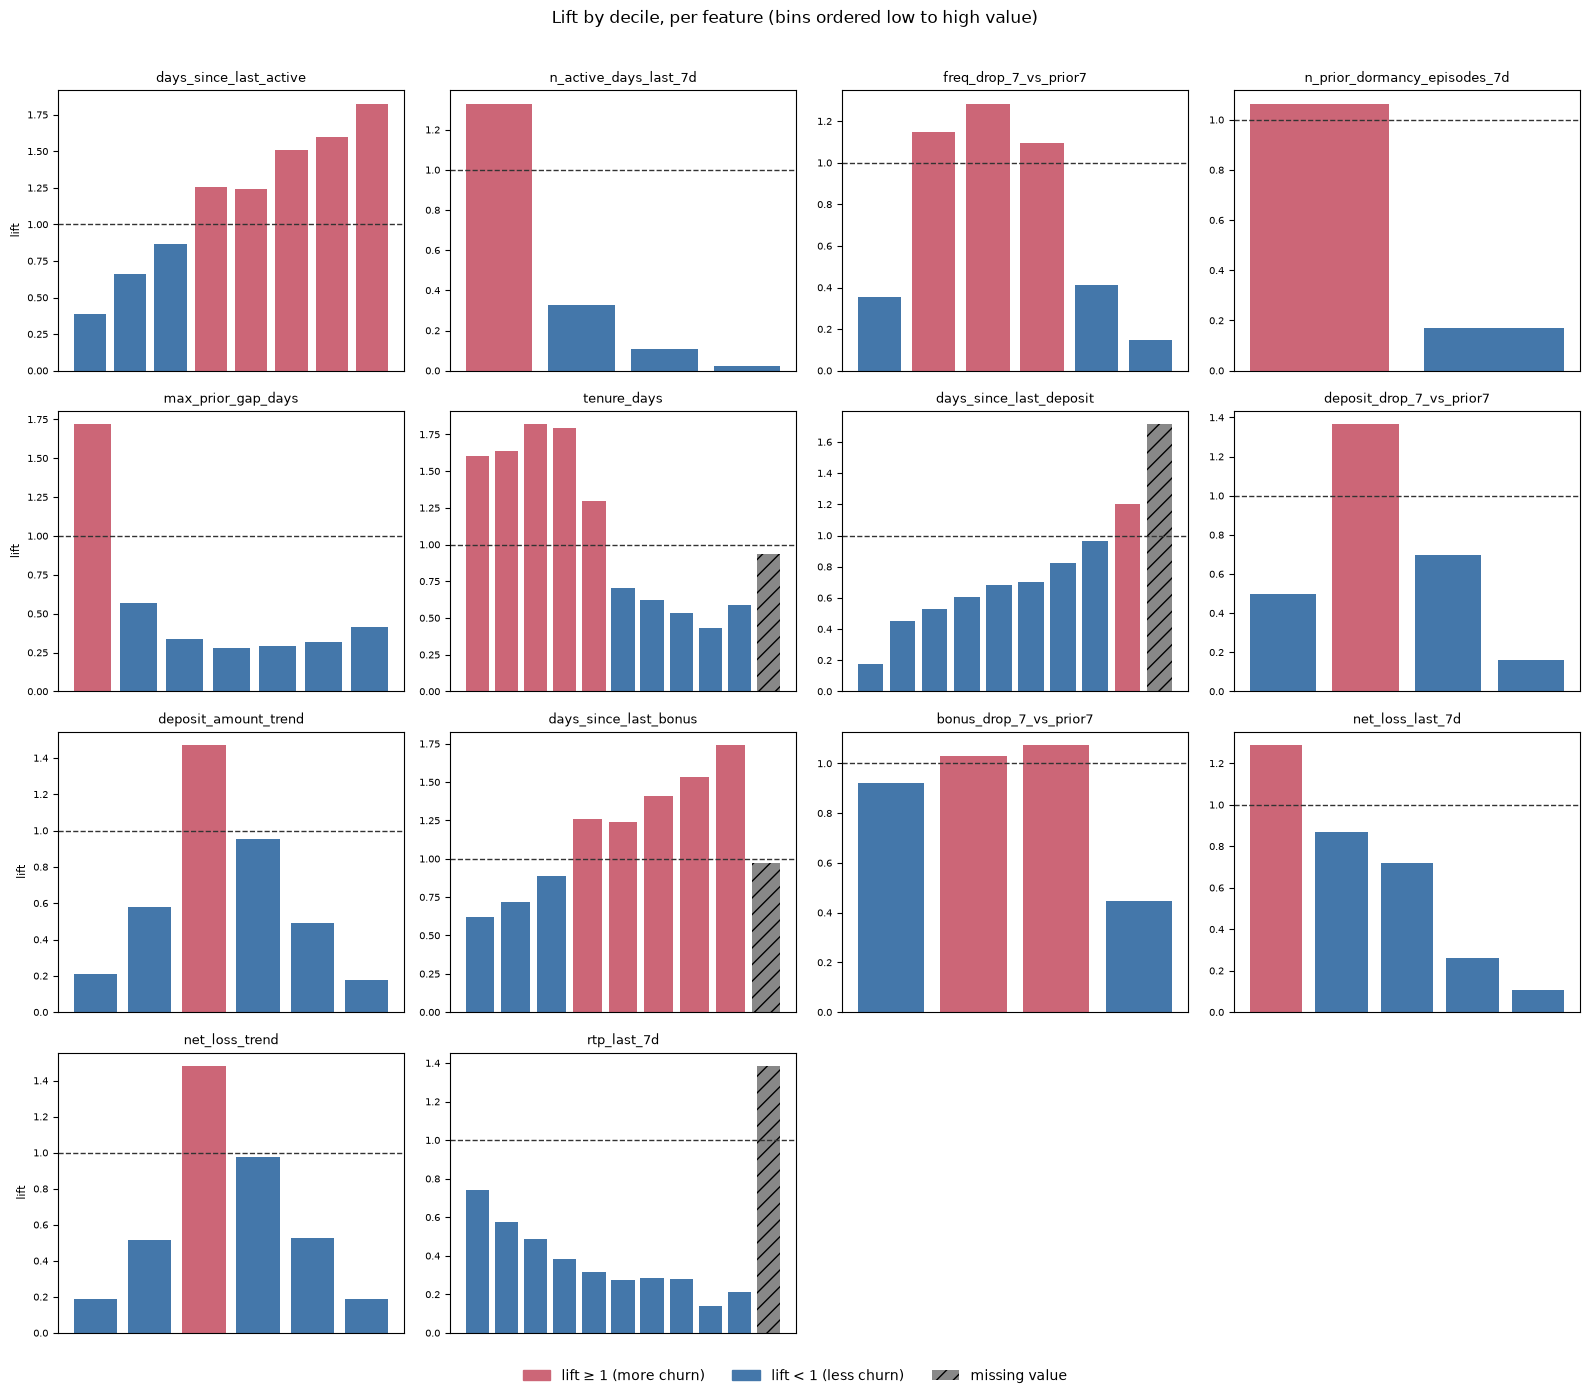

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

RISK_COLOR = "#CC6677"   # lift >= 1: bin churns more than baseline
SAFE_COLOR = "#4477AA"   # lift < 1: bin churns less than baseline
MISSING_COLOR = "#888888"

FIGURES_DIR = Path("../data/03_output")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(4, 4, figsize=(16, 14))
axes = axes.flatten()

for i, feat in enumerate(CANDIDATE_FEATURES):
    ax = axes[i]
    table, overall = lift_table(snapshots, feat)
    non_missing = table[table["bin"] != "missing"].reset_index(drop=True)
    n = len(non_missing)
    colors = [RISK_COLOR if l >= 1 else SAFE_COLOR for l in non_missing["lift"]]
    ax.bar(range(n), non_missing["lift"], color=colors, width=0.8)
    if "missing" in table["bin"].values:
        miss_lift = table.loc[table["bin"] == "missing", "lift"].iloc[0]
        ax.bar(n, miss_lift, color=MISSING_COLOR, width=0.8, hatch="//")
    ax.axhline(1.0, color="#333333", linewidth=1, linestyle="--")
    ax.set_title(feat, fontsize=9)
    ax.set_xticks([])
    ax.tick_params(labelsize=7)
    if i % 4 == 0:
        ax.set_ylabel("lift", fontsize=8)

for j in range(len(CANDIDATE_FEATURES), len(axes)):
    axes[j].axis("off")

legend_handles = [
    mpatches.Patch(color=RISK_COLOR, label="lift ≥ 1 (more churn)"),
    mpatches.Patch(color=SAFE_COLOR, label="lift < 1 (less churn)"),
    mpatches.Patch(facecolor=MISSING_COLOR, hatch="//", label="missing value"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.01), fontsize=10, frameon=False)
fig.suptitle("Lift by decile, per feature (bins ordered low to high value)", fontsize=12)
fig.tight_layout(rect=[0, 0.02, 1, 0.97])
fig.savefig(FIGURES_DIR / "lift_grid_brand64.png", dpi=150, bbox_inches="tight")
plt.show()

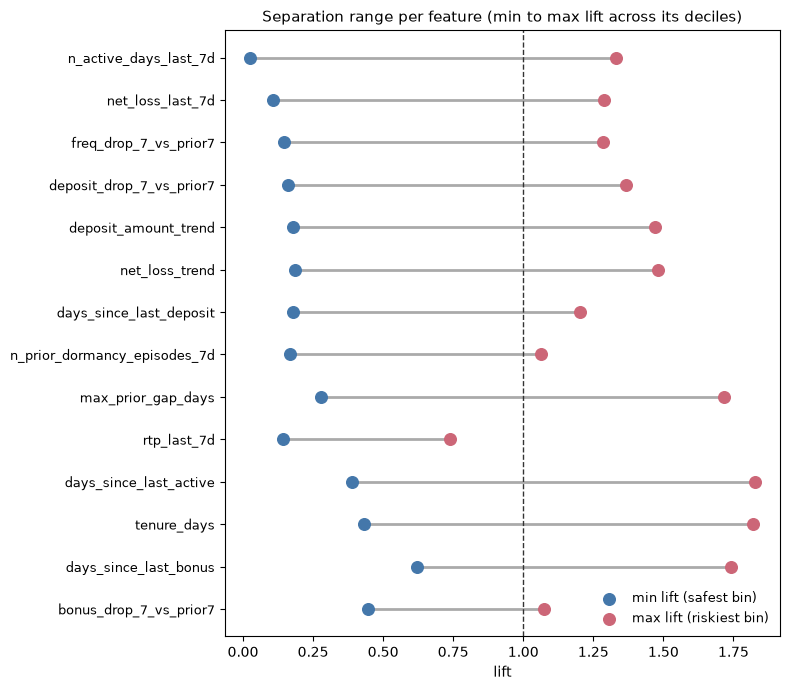

In [13]:
summary_sorted = lift_summary.sort_values("spread (max/min)", ascending=True).reset_index(drop=True)
y = np.arange(len(summary_sorted))

fig2, ax2 = plt.subplots(figsize=(8, 7))
ax2.hlines(y, summary_sorted["min_lift"], summary_sorted["max_lift"], color="#AAAAAA", linewidth=2, zorder=1)
ax2.scatter(summary_sorted["min_lift"], y, color=SAFE_COLOR, s=70, zorder=2, label="min lift (safest bin)")
ax2.scatter(summary_sorted["max_lift"], y, color=RISK_COLOR, s=70, zorder=2, label="max lift (riskiest bin)")
ax2.axvline(1.0, color="#333333", linewidth=1, linestyle="--")
ax2.set_yticks(y)
ax2.set_yticklabels(summary_sorted["feature"], fontsize=9)
ax2.set_xlabel("lift")
ax2.set_title("Separation range per feature (min to max lift across its deciles)", fontsize=11)
ax2.legend(loc="lower right", fontsize=9, frameon=False)
fig2.tight_layout()
fig2.savefig(FIGURES_DIR / "lift_summary_brand64.png", dpi=150, bbox_inches="tight")
plt.show()

### Risk, Cox Hazard Ratio

Lift above is univariate but static (one snapshot split into bins). A Cox proportional-hazards model gives the same "one feature at a time" read but as a continuous hazard ratio (HR) with a confidence interval and a p-value, which lift does not.


In [14]:
def build_return_time(cutoff, threshold_days=INACTIVITY_THRESHOLD_DAYS):
    """One row per player active by `cutoff`: days until their first return (or censored at threshold_days)."""
    pre = player_days[player_days["activity_date"] <= cutoff]
    post_end = cutoff + dt.timedelta(days=threshold_days)
    post = player_days[(player_days["activity_date"] > cutoff) & (player_days["activity_date"] <= post_end)]

    key = ["operator", "partyId"]
    risk_set = pre[key].drop_duplicates().reset_index(drop=True)
    first_return = post.groupby(key)["activity_date"].min().rename("first_return_date")
    out = risk_set.merge(first_return, on=key, how="left")
    out["duration"] = out["first_return_date"].apply(
        lambda d: (d - cutoff).days if pd.notna(d) else threshold_days
    )
    out["event_return"] = out["first_return_date"].notna().astype(int)
    out = out.drop(columns=["first_return_date"])
    out.insert(0, "cutoff_date", cutoff)
    return out


return_time = pd.concat([build_return_time(c) for c in CUTOFF_DATES], ignore_index=True)

# Sanity check: event_return must be exactly 1 - event_30d, same label, reframed.
check = return_time.merge(snapshots[["cutoff_date", "operator", "partyId", f"event_{INACTIVITY_THRESHOLD_DAYS}d"]],
                           on=["cutoff_date", "operator", "partyId"], how="left")
mismatch = (check["event_return"] != (1 - check[f"event_{INACTIVITY_THRESHOLD_DAYS}d"])).sum()
print(f"{len(return_time):,} rows, event_return rate: {return_time['event_return'].mean():.4f}")
print("mismatches vs 1 - event_30d (should be 0):", mismatch)
return_time["duration"].describe()

27,261 rows, event_return rate: 0.6152
mismatches vs 1 - event_30d (should be 0): 0


count    27261.000000
mean        29.033821
std         26.308652
min          1.000000
25%          3.000000
50%         17.000000
75%         60.000000
max         60.000000
Name: duration, dtype: float64

In [15]:
from lifelines import CoxPHFitter
from scipy.stats import false_discovery_control

SIGNED_LOG_FEATURES = {"net_loss_last_7d", "net_loss_trend", "deposit_amount_trend"}


def signed_log(x):
    return np.sign(x) * np.log1p(np.abs(x))


key = ["cutoff_date", "operator", "partyId"]
cox_rows = []

for feat in CANDIDATE_FEATURES:
    df = return_time.merge(snapshots[key + [feat]], on=key, how="left").dropna(subset=[feat])
    values = signed_log(df[feat]) if feat in SIGNED_LOG_FEATURES else df[feat]
    df["z"] = (values - values.mean()) / values.std() #standardize to 1 SD for HR interpretation

    cph = CoxPHFitter()
    cph.fit(df[["duration", "event_return", "z"]], duration_col="duration", event_col="event_return")
    s = cph.summary.loc["z"]

    cox_rows.append({
        "feature": feat,
        "n": len(df),
        "HR_per_1SD": s["exp(coef)"],
        "HR_lo95": s["exp(coef) lower 95%"],
        "HR_hi95": s["exp(coef) upper 95%"],
        "p": s["p"],
    })
    print(f"{feat}: HR={s['exp(coef)']:.3f} [{s['exp(coef) lower 95%']:.3f}, {s['exp(coef) upper 95%']:.3f}] p={s['p']:.2e}")

cox_summary = pd.DataFrame(cox_rows)
cox_summary["p_bh"] = false_discovery_control(cox_summary["p"], method="bh")
cox_summary = cox_summary.sort_values("HR_per_1SD").reset_index(drop=True)
cox_summary

days_since_last_active: HR=0.484 [0.474, 0.495] p=0.00e+00
n_active_days_last_7d: HR=2.309 [2.278, 2.342] p=0.00e+00
freq_drop_7_vs_prior7: HR=1.105 [1.085, 1.126] p=1.51e-26
n_prior_dormancy_episodes_7d: HR=1.466 [1.448, 1.485] p=0.00e+00
max_prior_gap_days: HR=1.459 [1.442, 1.476] p=0.00e+00
tenure_days: HR=1.503 [1.471, 1.536] p=1.83e-301
days_since_last_deposit: HR=0.601 [0.588, 0.614] p=0.00e+00
deposit_drop_7_vs_prior7: HR=1.200 [1.176, 1.224] p=1.35e-71
deposit_amount_trend: HR=1.081 [1.060, 1.102] p=1.04e-14
days_since_last_bonus: HR=0.595 [0.575, 0.615] p=6.18e-198
bonus_drop_7_vs_prior7: HR=1.049 [1.030, 1.068] p=1.47e-07
net_loss_last_7d: HR=1.690 [1.660, 1.720] p=0.00e+00
net_loss_trend: HR=1.014 [0.994, 1.034] p=1.59e-01
rtp_last_7d: HR=1.130 [1.116, 1.144] p=2.12e-81


,feature,n,HR_per_1SD,HR_lo95,HR_hi95,p,p_bh
0,days_since_last_active,27261,0.484045,0.473726,0.494590,0.000000e+00,0.000000e+00
1,days_since_last_bonus,9673,0.594683,0.574840,0.615212,6.180072e-198,1.081513e-197
2,days_since_last_deposit,17333,0.600931,0.588328,0.613805,0.000000e+00,0.000000e+00
3,net_loss_trend,27261,1.014223,0.994483,1.034356,1.590424e-01,1.590424e-01
4,bonus_drop_7_vs_prior7,27261,1.048820,1.030343,1.067629,1.472063e-07,1.585298e-07
5,deposit_amount_trend,27261,1.080631,1.059603,1.102077,1.040672e-14,1.214118e-14
6,freq_drop_7_vs_prior7,27261,1.105130,1.085011,1.125623,1.507167e-26,1.918213e-26
7,rtp_last_7d,10340,1.129944,1.115873,1.144191,2.124542e-81,3.304843e-81
8,deposit_drop_7_vs_prior7,27261,1.199803,1.176100,1.223984,1.349358e-71,1.889101e-71
9,max_prior_gap_days,27261,1.459074,1.442378,1.475963,0.000000e+00,0.000000e+00


#### Save and visualize



In [16]:
COX_SUMMARY_CACHE = Path("../data/02_intermediate/cox_hr_summary_brand64.parquet")
cox_summary.to_parquet(COX_SUMMARY_CACHE)
print(f"saved {COX_SUMMARY_CACHE} ({len(cox_summary)} rows)")

COX_SUMMARY_OUTPUT = Path("../data/03_output/cox_hr_summary_brand64.parquet")
cox_summary.to_parquet(COX_SUMMARY_OUTPUT)
print(f"saved {COX_SUMMARY_OUTPUT} (final table, same content)")

saved ../data/02_intermediate/cox_hr_summary_brand64.parquet (14 rows)
saved ../data/03_output/cox_hr_summary_brand64.parquet (final table, same content)


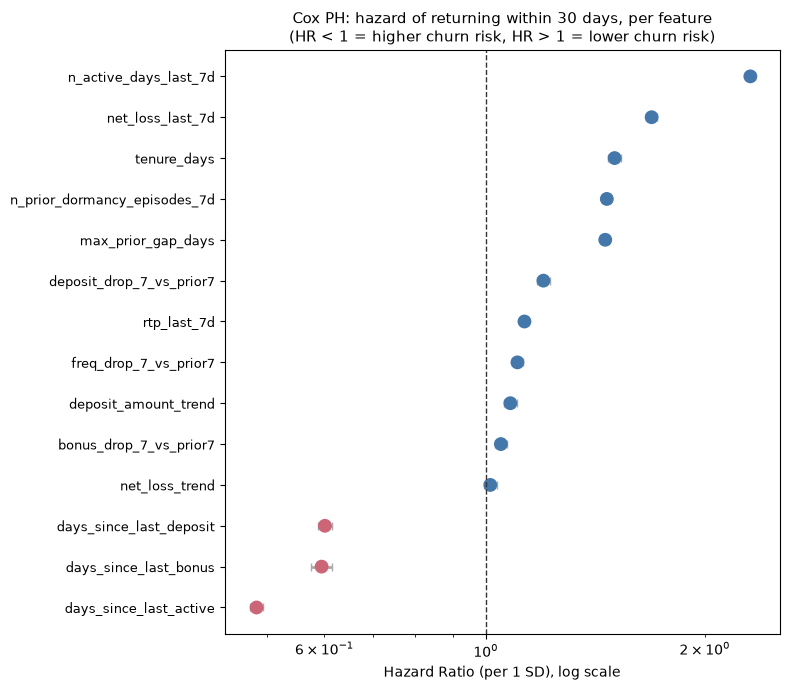

In [17]:
y = np.arange(len(cox_summary))
colors = [RISK_COLOR if hr < 1 else SAFE_COLOR for hr in cox_summary["HR_per_1SD"]]

fig3, ax3 = plt.subplots(figsize=(8, 7))
xerr_lo = cox_summary["HR_per_1SD"] - cox_summary["HR_lo95"]
xerr_hi = cox_summary["HR_hi95"] - cox_summary["HR_per_1SD"]
ax3.errorbar(cox_summary["HR_per_1SD"], y, xerr=[xerr_lo, xerr_hi], fmt="none",
             ecolor="#AAAAAA", elinewidth=2, capsize=3, zorder=1)
ax3.scatter(cox_summary["HR_per_1SD"], y, color=colors, s=80, zorder=2)
ax3.axvline(1.0, color="#333333", linewidth=1, linestyle="--")
ax3.set_xscale("log")
ax3.set_yticks(y)
ax3.set_yticklabels(cox_summary["feature"], fontsize=9)
ax3.set_xlabel("Hazard Ratio (per 1 SD), log scale")
ax3.set_title(
    "Cox PH: hazard of returning within 30 days, per feature\n"
    "(HR < 1 = higher churn risk, HR > 1 = lower churn risk)",
    fontsize=11,
)
fig3.tight_layout()
fig3.savefig(FIGURES_DIR / "cox_hr_forest_brand64.png", dpi=150, bbox_inches="tight")
plt.show()

**Result.** Full ranking for `brandId=64` (14 features, sorted by HR):

| feature | n | HR (per 1 SD) | p_bh |
|---|---|---|---|
| days_since_last_active | 27,261 | 0.484 | ~0 |
| days_since_last_bonus | 9,673 | 0.595 | ~0 |
| days_since_last_deposit | 17,333 | 0.601 | ~0 |
| net_loss_trend | 27,261 | 1.014 | 0.159 |
| bonus_drop_7_vs_prior7 | 27,261 | 1.049 | ~0 |
| deposit_amount_trend | 27,261 | 1.081 | ~0 |
| freq_drop_7_vs_prior7 | 27,261 | 1.105 | ~0 |
| rtp_last_7d | 10,340 | 1.130 | ~0 |
| deposit_drop_7_vs_prior7 | 27,261 | 1.200 | ~0 |
| max_prior_gap_days | 27,261 | 1.459 | ~0 |
| n_prior_dormancy_episodes_7d | 27,261 | 1.466 | ~0 |
| tenure_days | 10,773 | 1.503 | ~0 |
| net_loss_last_7d | 27,261 | 1.690 | ~0 |
| n_active_days_last_7d | 27,261 | 2.309 | ~0 |

Same direction as the all-brands pass throughout. The real difference from the all-brands run, flagged in the methodology above as a known limitation there, shows up here exactly as predicted: with 27,261 rows instead of 1.7M, the p-value is finally informative again. **`net_loss_trend` is the one feature that comes back not significant** (`p_bh = 0.159`), consistent with its HR sitting almost exactly at 1 (1.014) and with the flat, confounded result already seen for this feature in the money-features Result above. Every other feature stays clearly significant even at this much smaller sample size, their effect sizes are large enough to not depend on the sample-size inflation that made every single feature "significant" in the all-brands pass.

### Stratified Kaplan-Meier: time-to-return curves by feature group

Lift and the Cox HR both summarize a feature into a single number per bin or a single HR. A stratified KM curve shows the whole return-time path instead, overlaying one "P(not yet returned)" curve per group of a feature, on the same `duration` / `event_return` pair used for Cox (see above): `duration` = days from cutoff `T` to first return (or 30 if censored), `event_return` = 1 if they returned. A curve that stays near 1.0 longer means that group is slower to return (higher churn risk); a curve that drops fast means that group returns quickly (lower churn risk). Run for all 14 candidate features, not just an illustrative few.

**Two grouping strategies, picked per feature:**
- **Value deciles** (`km_by_tertile`, despite the name it requests 10 quantile bins like `lift_table`, not a fixed 3, `qcut` collapses to however many survive): for the 9 "level" features (`days_since_last_active`, `n_active_days_last_7d`, `n_prior_dormancy_episodes_7d`, `max_prior_gap_days`, `tenure_days`, `days_since_last_deposit`, `days_since_last_bonus`, `net_loss_last_7d`, `rtp_last_7d`). Color tracks the **feature value** (blue = low, red = high), not the risk direction, because that direction is not always the same, `tenure_days` and `max_prior_gap_days` are both non-monotonic (confirmed below), so the reddest and bluest curves are not the risk extremes.
- **A refined, hand-built 4-group split** for the 5 "difference" features (`freq_drop_7_vs_prior7`, `deposit_drop_7_vs_prior7`, `bonus_drop_7_vs_prior7`, `net_loss_trend`, `deposit_amount_trend`). A first attempt on `freq_drop_7_vs_prior7` split players by sign (declining / stable / increasing), but 91% of "stable" (`drop = 0`) turned out to be players with **zero** activity in both the last-7d and prior-7d windows, already fully dormant before the cutoff, not stable-and-active. Checking the other four difference features found the same confound, worse in three of them: 87-99.8% of their "stable" rows are also both-windows-zero. Fixed the same way for all five: an explicit `already dormant` group carved out first, so `stable-active` only contains players with the same non-zero level in both windows.

A log-rank test (`multivariate_logrank_test`) is run per panel to confirm the groups are statistically different, not just visually different (expect p ≈ 0 everywhere at 1.7M rows, same large-sample caveat as the Cox section).

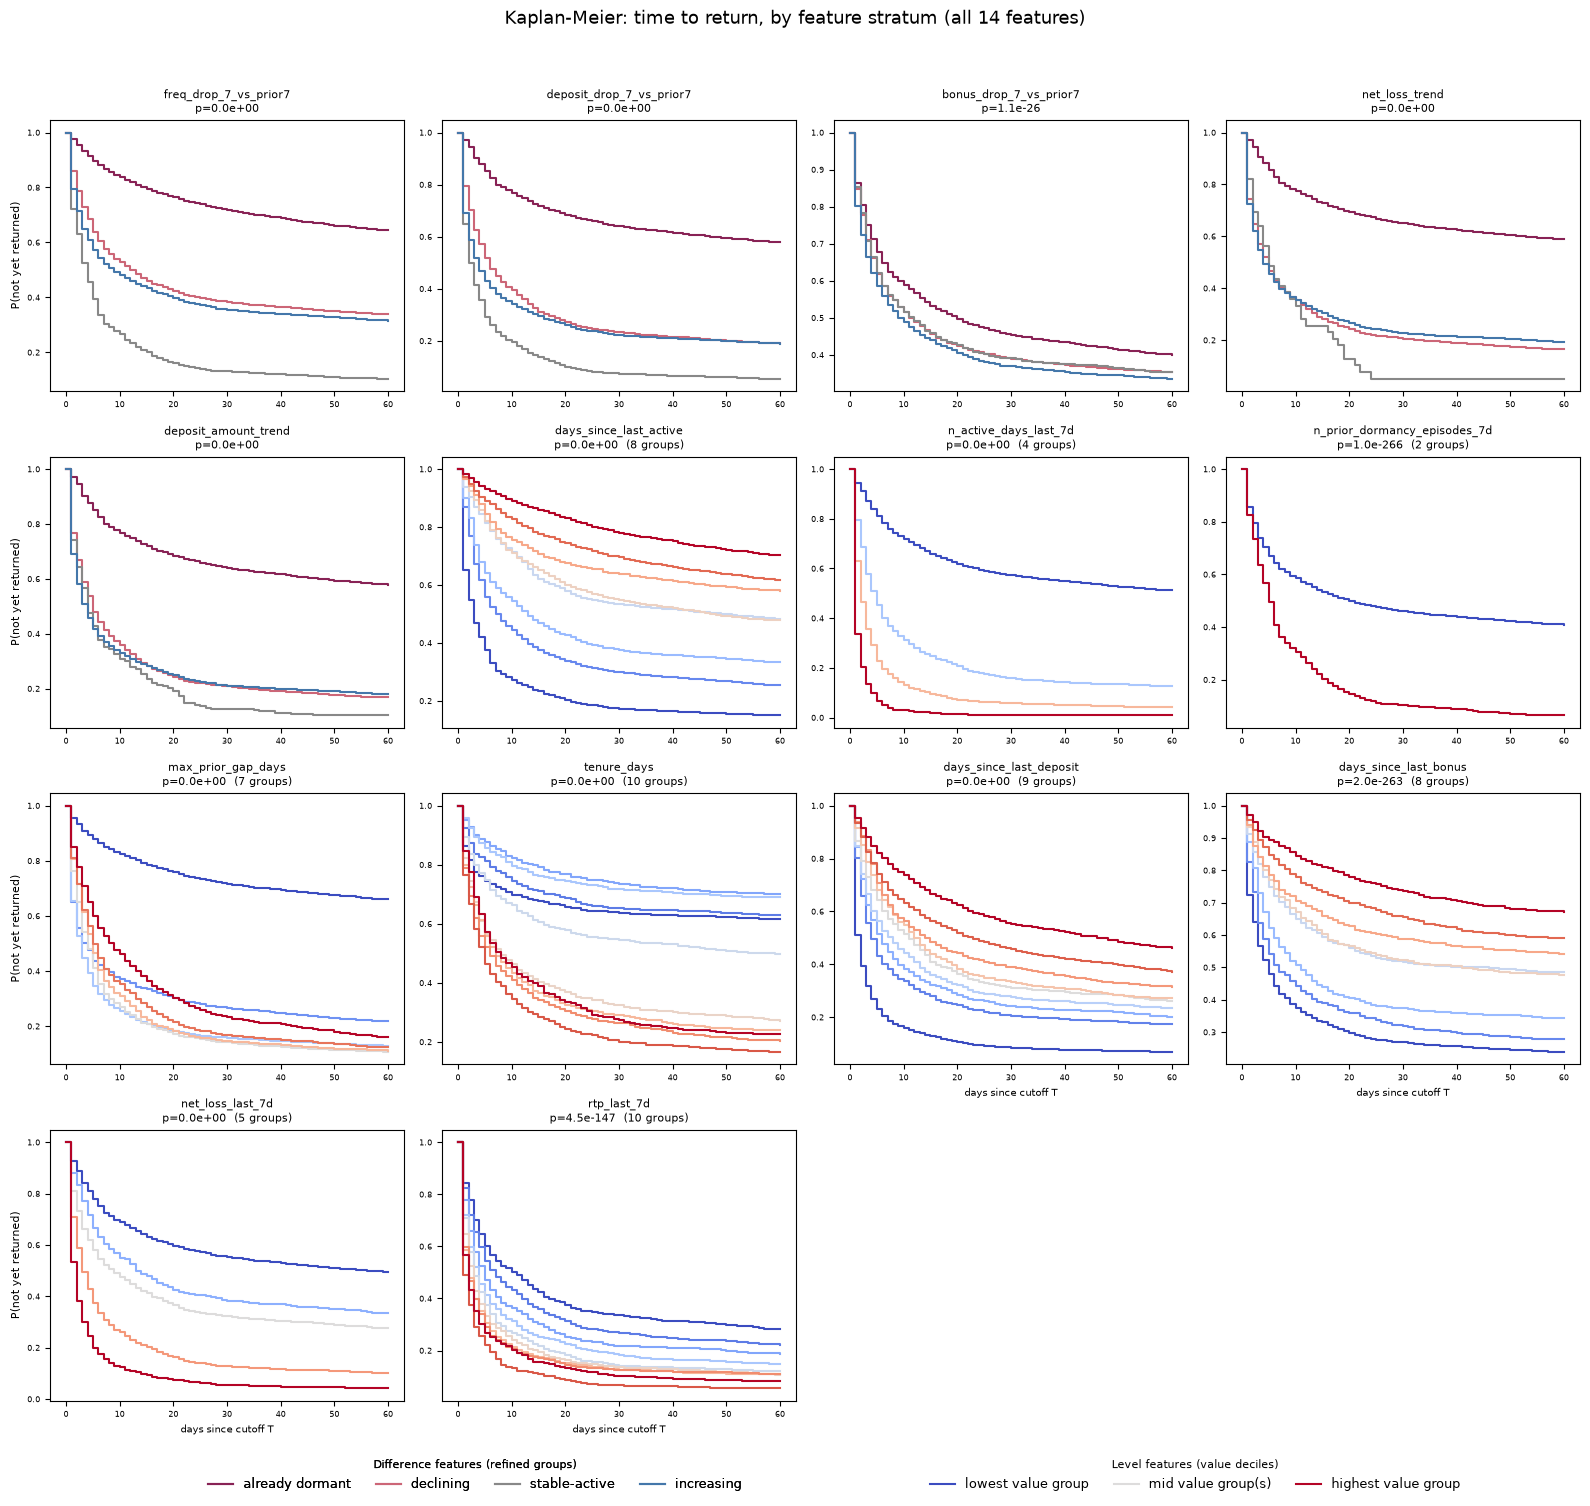

In [18]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.lines as mlines

DIFF_FEATURES = {
    "freq_drop_7_vs_prior7": ("n_active_days_last_7d", "n_active_days_prior_7d"),
    "deposit_drop_7_vs_prior7": ("n_deposit_last_7d", "n_deposit_prior_7d"),
    "bonus_drop_7_vs_prior7": ("n_bonus_last_7d", "n_bonus_prior_7d"),
    "net_loss_trend": ("stake_last_7d", "stake_prior_7d"),
    "deposit_amount_trend": ("deposit_amount_last_7d", "deposit_amount_prior_7d"),
}
LEVEL_FEATURES = [
    "days_since_last_active", "n_active_days_last_7d", "n_prior_dormancy_episodes_7d",
    "max_prior_gap_days", "tenure_days", "days_since_last_deposit", "days_since_last_bonus",
    "net_loss_last_7d", "rtp_last_7d",
]
KM_ALL_FEATURES = list(DIFF_FEATURES.keys()) + LEVEL_FEATURES


def km_by_tertile(feat, ax, n_groups=10):
    """Overlaid KM 'time to return' curves for `feat`, split into up to `n_groups` quantile bins."""
    df = return_time.merge(snapshots[key + [feat]], on=key, how="left").dropna(subset=[feat])
    df["group"] = pd.qcut(df[feat], n_groups, duplicates="drop", labels=False)
    n = df["group"].nunique()
    colors = plt.cm.coolwarm(np.linspace(0, 1, n))
    for g in sorted(df["group"].unique()):
        grp = df[df["group"] == g]
        kmf = KaplanMeierFitter()
        kmf.fit(grp["duration"], event_observed=grp["event_return"])
        kmf.plot_survival_function(ax=ax, ci_show=False, color=colors[g], legend=False)
    result = multivariate_logrank_test(df["duration"], df["group"], df["event_return"])
    ax.set_title(f"{feat}\np={result.p_value:.1e}  ({n} groups)", fontsize=8)
    ax.tick_params(labelsize=6)
    ax.set_xlabel("")
    ax.set_ylabel("")


def km_diff_refined(feat, last7_col, prior7_col, ax):
    """Hand-built groups for a last7-vs-prior7 'drop' feature, carving out the already-dormant confound."""
    df = return_time.merge(snapshots[key + [feat, last7_col, prior7_col]], on=key, how="left").dropna(subset=[feat])

    def refined_group(row):
        if row[last7_col] == 0 and row[prior7_col] == 0:
            return "already dormant"
        if row[feat] < 0:
            return "declining"
        if row[feat] > 0:
            return "increasing"
        return "stable-active"

    df["group"] = df.apply(refined_group, axis=1)
    group_colors = {"already dormant": "#882255", "declining": "#CC6677", "stable-active": "#888888", "increasing": "#4477AA"}
    for g in ["already dormant", "declining", "stable-active", "increasing"]:
        grp = df[df["group"] == g]
        if len(grp) == 0:
            continue
        kmf = KaplanMeierFitter()
        kmf.fit(grp["duration"], event_observed=grp["event_return"])
        kmf.plot_survival_function(ax=ax, ci_show=False, color=group_colors[g], legend=False)
    result = multivariate_logrank_test(df["duration"], df["group"], df["event_return"])
    ax.set_title(f"{feat}\np={result.p_value:.1e}", fontsize=8)
    ax.tick_params(labelsize=6)
    ax.set_xlabel("")
    ax.set_ylabel("")


fig5, axes5 = plt.subplots(4, 4, figsize=(16, 15))
axes5 = axes5.flatten()
for i, feat in enumerate(KM_ALL_FEATURES):
    ax = axes5[i]
    if feat in DIFF_FEATURES:
        last7_col, prior7_col = DIFF_FEATURES[feat]
        km_diff_refined(feat, last7_col, prior7_col, ax)
    else:
        km_by_tertile(feat, ax)
    if i % 4 == 0:
        ax.set_ylabel("P(not yet returned)", fontsize=8)
    if i >= len(KM_ALL_FEATURES) - 4:
        ax.set_xlabel("days since cutoff T", fontsize=7)
for j in range(len(KM_ALL_FEATURES), len(axes5)):
    axes5[j].axis("off")

diff_handles = [
    mlines.Line2D([], [], color="#882255", label="already dormant"),
    mlines.Line2D([], [], color="#CC6677", label="declining"),
    mlines.Line2D([], [], color="#888888", label="stable-active"),
    mlines.Line2D([], [], color="#4477AA", label="increasing"),
]
level_handles = [
    mlines.Line2D([], [], color=plt.cm.coolwarm(0.0), label="lowest value group"),
    mlines.Line2D([], [], color=plt.cm.coolwarm(0.5), label="mid value group(s)"),
    mlines.Line2D([], [], color=plt.cm.coolwarm(1.0), label="highest value group"),
]
leg1 = fig5.legend(handles=diff_handles, loc="lower center", ncol=4, bbox_to_anchor=(0.3, -0.015),
                    fontsize=9, frameon=False, title="Difference features (refined groups)", title_fontsize=8)
fig5.legend(handles=level_handles, loc="lower center", ncol=3, bbox_to_anchor=(0.75, -0.015),
            fontsize=9, frameon=False, title="Level features (value deciles)", title_fontsize=8)
fig5.add_artist(leg1)

fig5.suptitle("Kaplan-Meier: time to return, by feature stratum (all 14 features)", fontsize=13)
fig5.tight_layout(rect=[0, 0.02, 1, 0.96])
fig5.savefig(FIGURES_DIR / "km_by_stratum_brand64.png", dpi=150, bbox_inches="tight")
plt.show()

**Result.** All 14 panels for `brandId=64`, same direction as lift and Cox throughout. Three things worth calling out:

- **`n_prior_dormancy_episodes_7d` is still inverted**, same confound as the all-brands pass (can only be nonzero for players with enough pre-cutoff history), now even more pronounced at this brand's event rate: 0 episodes has lift 1.06, 2+ episodes has lift 0.17 (see the lift Result above).
- **`tenure_days` and `max_prior_gap_days` are both still non-monotonic**, and more sharply so for this brand: `tenure_days`' riskiest group is 13-25 days of tenure (lift 1.82), not the newest players (0-5 days, lift 1.60) or the most established (1021-1267 days, lift 0.43). Same peak-in-the-middle shape as the all-brands pass, same conclusion: bucket this feature, do not feed it in as a raw linear value.
- **`rtp_last_7d`'s missing bucket is still the strongest single signal in its own chart** (lift 1.39, versus its own real-value bins which top out at 0.74), same story as the all-brands pass: not betting recently is a stronger churn signal than any observed RTP value.

Saved to `data/03_output/km_by_stratum_brand64.png`.

## Decision matrix: quantitative scoring

Changed from the earlier qualitative version (judgment calls about confounds and missingness) to a purely numeric one, built only from the three quantitative results already computed in this notebook: lift, the Cox hazard ratio with its p-value, and the stratified KM curves.

**Three magnitudes, not three verdicts:**
- **LIFT**: `lift_spread` = max/min lift across deciles (already computed above).
- **Hazard Ratio**: `|log2(HR_per_1SD)|`, distance from `HR=1` on a log scale (symmetric for HR above vs. below 1, e.g. HR=2 and HR=0.5 score the same distance).
- **KM**: `km_spread_day30` = the spread in `P(not yet returned)` at day 30 across a feature's own groups (same grouping as the KM section: refined 4-group for the 5 difference features, deciles for the other 9), the magnitude version of what the log-rank test only tells you is "different."

**p-values are reported, not used to rank.** Both `cox_p_bh` and a new `logrank_p_bh` (log-rank test per feature, same Benjamini-Hochberg correction) are in the table, but at 1.7M rows they are ≈ 0 for all 14 features (already flagged in the Cox and KM sections), so they do not separate anything here, the ranking comes entirely from the three magnitudes.





In [20]:
from lifelines.statistics import multivariate_logrank_test


def km_spread_at_day(df, day=INACTIVITY_THRESHOLD_DAYS):
    probs = {}
    for g, grp in df.groupby("group", observed=True):
        kmf = KaplanMeierFitter()
        kmf.fit(grp["duration"], event_observed=grp["event_return"])
        sf = kmf.survival_function_
        probs[g] = sf[sf.index <= day].iloc[-1, 0] if (sf.index <= day).any() else sf.iloc[0, 0]
    vals = list(probs.values())
    return max(vals) - min(vals)


quant_rows = []
for feat in CANDIDATE_FEATURES:
    t, _ = lift_table(snapshots, feat)
    nm = t[t["bin"] != "missing"]
    lift_spread = nm["lift"].max() / nm["lift"].min()

    if feat in DIFF_FEATURES:
        last7_col, prior7_col = DIFF_FEATURES[feat]
        df = return_time.merge(
            snapshots[key + [feat, last7_col, prior7_col]], on=key, how="left"
        ).dropna(subset=[feat])

        def refined_group(row, feat=feat, last7_col=last7_col, prior7_col=prior7_col):
            if row[last7_col] == 0 and row[prior7_col] == 0:
                return "already dormant"
            if row[feat] < 0:
                return "declining"
            if row[feat] > 0:
                return "increasing"
            return "stable-active"

        df["group"] = df.apply(refined_group, axis=1)
    else:
        df = return_time.merge(snapshots[key + [feat]], on=key, how="left").dropna(subset=[feat])
        df["group"] = pd.qcut(df[feat], 10, duplicates="drop", labels=False)

    lr = multivariate_logrank_test(df["duration"], df["group"], df["event_return"])
    km_spread = km_spread_at_day(df, day=INACTIVITY_THRESHOLD_DAYS)

    cox_row = cox_summary.set_index("feature").loc[feat]
    quant_rows.append({
        "feature": feat,
        "lift_spread": lift_spread,
        "HR_per_1SD": cox_row["HR_per_1SD"],
        "cox_p": cox_row["p"],
        "logrank_p": lr.p_value,
        f"km_spread_day{INACTIVITY_THRESHOLD_DAYS}": km_spread,
    })

decision_matrix = pd.DataFrame(quant_rows)
decision_matrix["cox_p_bh"] = false_discovery_control(decision_matrix["cox_p"], method="bh")
decision_matrix["logrank_p_bh"] = false_discovery_control(decision_matrix["logrank_p"], method="bh")
decision_matrix["abs_log2_HR"] = np.log2(decision_matrix["HR_per_1SD"]).abs()


def normalize(s):
    return (s - s.min()) / (s.max() - s.min())


decision_matrix["lift_norm"] = normalize(decision_matrix["lift_spread"])
decision_matrix["hr_norm"] = normalize(decision_matrix["abs_log2_HR"])
decision_matrix["km_norm"] = normalize(decision_matrix[f"km_spread_day{INACTIVITY_THRESHOLD_DAYS}"])
decision_matrix["composite"] = decision_matrix[["lift_norm", "hr_norm", "km_norm"]].mean(axis=1)

t1, t2 = decision_matrix["composite"].quantile([1 / 3, 2 / 3]).values
decision_matrix["tier"] = decision_matrix["composite"].apply(
    lambda c: "HIGH" if c >= t2 else ("MEDIUM" if c >= t1 else "LOW")
)
decision_matrix = decision_matrix.sort_values("composite", ascending=False).reset_index(drop=True)

DECISION_MATRIX_CACHE = Path("../data/02_intermediate/feature_decision_matrix_brand64.parquet")
decision_matrix.to_parquet(DECISION_MATRIX_CACHE)
decision_matrix.to_parquet(Path("../data/03_output/feature_decision_matrix_brand64.parquet"))
print(f"saved {DECISION_MATRIX_CACHE} and the data/03_output copy ({len(decision_matrix)} rows)")
print(decision_matrix["tier"].value_counts())
decision_matrix[["feature", "tier", "composite", "lift_spread", "abs_log2_HR", f"km_spread_day{INACTIVITY_THRESHOLD_DAYS}", "cox_p_bh", "logrank_p_bh"]].round(3)

saved ../data/02_intermediate/feature_decision_matrix_brand64.parquet and the data/03_output copy (14 rows)
tier
HIGH      5
LOW       5
MEDIUM    4
Name: count, dtype: int64


,feature,tier,composite,lift_spread,abs_log2_HR,km_spread_day60,cox_p_bh,logrank_p_bh
0,n_active_days_last_7d,HIGH,0.965,56.090,1.208,0.503,0.000,0.0
1,days_since_last_active,HIGH,0.635,4.681,1.047,0.552,0.000,0.0
2,net_loss_last_7d,HIGH,0.532,12.061,0.757,0.454,0.000,0.0
3,max_prior_gap_days,HIGH,0.504,6.180,0.545,0.554,0.000,0.0
4,tenure_days,HIGH,0.490,4.210,0.588,0.534,0.000,0.0
5,days_since_last_bonus,MEDIUM,0.457,2.805,0.750,0.431,0.000,0.0
6,days_since_last_deposit,MEDIUM,0.452,6.732,0.735,0.394,0.000,0.0
7,deposit_drop_7_vs_prior7,MEDIUM,0.419,8.429,0.263,0.524,0.000,0.0
8,freq_drop_7_vs_prior7,MEDIUM,0.398,8.802,0.144,0.539,0.000,0.0
9,n_prior_dormancy_episodes_7d,LOW,0.365,6.321,0.552,0.345,0.000,0.0


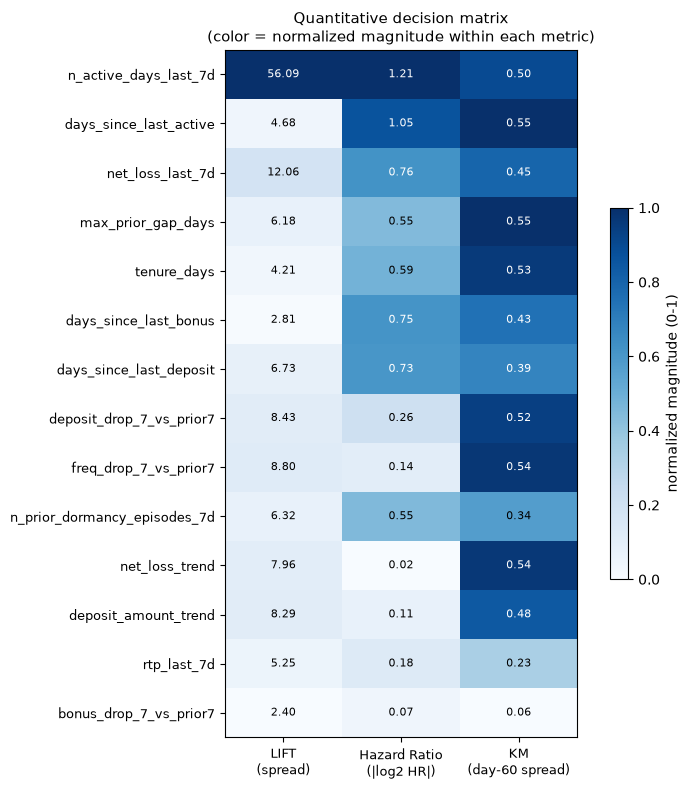

In [22]:
heat = decision_matrix.set_index("feature")[["lift_norm", "hr_norm", "km_norm"]]
raw = decision_matrix.set_index("feature")[["lift_spread", "abs_log2_HR", f"km_spread_day{INACTIVITY_THRESHOLD_DAYS}"]]

fig7, ax7 = plt.subplots(figsize=(7, 8))
im = ax7.imshow(heat.values, cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax7.set_xticks(range(3))
ax7.set_xticklabels(["LIFT\n(spread)", "Hazard Ratio\n(|log2 HR|)", f"KM\n(day-{INACTIVITY_THRESHOLD_DAYS} spread)"], fontsize=9)
ax7.set_yticks(range(len(heat)))
ax7.set_yticklabels(heat.index, fontsize=9)
for i in range(len(heat)):
    for j, col in enumerate(["lift_spread", "abs_log2_HR", f"km_spread_day{INACTIVITY_THRESHOLD_DAYS}"]):
        color = "white" if heat.values[i, j] > 0.6 else "black"
        ax7.text(j, i, f"{raw.iloc[i][col]:.2f}", ha="center", va="center", fontsize=8, color=color)
ax7.set_title("Quantitative decision matrix\n(color = normalized magnitude within each metric)", fontsize=11)
fig7.colorbar(im, ax=ax7, label="normalized magnitude (0-1)", fraction=0.046, pad=0.08)
fig7.tight_layout()
fig7.savefig(FIGURES_DIR / "decision_matrix_brand64.png", dpi=150, bbox_inches="tight")
plt.show()